In [ ]:
!pip install requests pandas

In [ ]:
import requests
import pandas as pd

# WHO API endpoint for life expectancy
url = "https://ghoapi.azureedge.net/api/WHOSIS_000001"

response = requests.get(url)
data = response.json()

# Extract the actual records
records = data['value']

# Convert to DataFrame
df = pd.DataFrame(records)

# Show first rows
df.head()

,Id,IndicatorCode,SpatialDimType,SpatialDim,ParentLocationCode,TimeDimType,ParentLocation,Dim1Type,TimeDim,Dim1,...,DataSourceDim,Value,NumericValue,Low,High,Comments,Date,TimeDimensionValue,TimeDimensionBegin,TimeDimensionEnd
0,2948593,WHOSIS_000001,COUNTRY,BEL,EUR,YEAR,Europe,SEX,2009,SEX_BTSX,...,None,79.8 [79.8-79.9],79.826653,79.814581,79.909561,None,2024-08-02T09:43:39.193+02:00,2009,2009-01-01T00:00:00+01:00,2009-12-31T00:00:00+01:00
1,2948905,WHOSIS_000001,COUNTRY,TCD,AFR,YEAR,Africa,SEX,2019,SEX_MLE,...,None,57.8 [56.6-59.2],57.838801,56.588937,59.192508,None,2024-08-02T09:43:39.193+02:00,2019,2019-01-01T00:00:00+01:00,2019-12-31T00:00:00+01:00
2,2949004,WHOSIS_000001,COUNTRY,MAR,EMR,YEAR,Eastern Mediterranean,SEX,2015,SEX_MLE,...,None,72.4 [71.7-73.3],72.441505,71.747894,73.298109,None,2024-08-02T09:43:39.193+02:00,2015,2015-01-01T00:00:00+01:00,2015-12-31T00:00:00+01:00
3,2949377,WHOSIS_000001,COUNTRY,BRA,AMR,YEAR,Americas,SEX,2000,SEX_MLE,...,None,68.2 [67.9-68.5],68.158726,67.890006,68.488454,None,2024-08-02T09:43:39.193+02:00,2000,2000-01-01T00:00:00+01:00,2000-12-31T00:00:00+01:00
4,2950085,WHOSIS_000001,COUNTRY,TON,WPR,YEAR,Western Pacific,SEX,2014,SEX_BTSX,...,None,72.4 [71.8-73.0],72.381824,71.818791,73.021260,None,2024-08-02T09:43:39.193+02:00,2014,2014-01-01T00:00:00+01:00,2014-12-31T00:00:00+01:00


In [ ]:
df.columns

Index(['Id', 'IndicatorCode', 'SpatialDimType', 'SpatialDim',
       'ParentLocationCode', 'TimeDimType', 'ParentLocation', 'Dim1Type',
       'TimeDim', 'Dim1', 'Dim2Type', 'Dim2', 'Dim3Type', 'Dim3',
       'DataSourceDimType', 'DataSourceDim', 'Value', 'NumericValue', 'Low',
       'High', 'Comments', 'Date', 'TimeDimensionValue', 'TimeDimensionBegin',
       'TimeDimensionEnd'],
      dtype='object')

In [ ]:
df_usa = df[df['SpatialDim'] == 'USA']
df_usa.head()

,Id,IndicatorCode,SpatialDimType,SpatialDim,ParentLocationCode,TimeDimType,ParentLocation,Dim1Type,TimeDim,Dim1,...,DataSourceDim,Value,NumericValue,Low,High,Comments,Date,TimeDimensionValue,TimeDimensionBegin,TimeDimensionEnd
173,3078438,WHOSIS_000001,COUNTRY,USA,AMR,YEAR,Americas,SEX,2011,SEX_FMLE,...,None,80.8 [80.8-80.8],80.797122,80.750904,80.843339,None,2024-08-02T09:43:39.193+02:00,2011,2011-01-01T00:00:00+01:00,2011-12-31T00:00:00+01:00
544,3352210,WHOSIS_000001,COUNTRY,USA,AMR,YEAR,Americas,SEX,2006,SEX_FMLE,...,None,80.0 [79.9-80.0],79.992430,79.941158,80.043701,None,2024-08-02T09:43:39.193+02:00,2006,2006-01-01T00:00:00+01:00,2006-12-31T00:00:00+01:00
1583,238089,WHOSIS_000001,COUNTRY,USA,AMR,YEAR,Americas,SEX,2008,SEX_FMLE,...,None,80.3 [80.2-80.3],80.283724,80.237185,80.330263,None,2024-08-02T09:43:39.193+02:00,2008,2008-01-01T00:00:00+01:00,2008-12-31T00:00:00+01:00
1608,256636,WHOSIS_000001,COUNTRY,USA,AMR,YEAR,Americas,SEX,2006,SEX_BTSX,...,None,77.7 [77.6-77.7],77.683314,77.633223,77.733404,None,2024-08-02T09:43:39.193+02:00,2006,2006-01-01T00:00:00+01:00,2006-12-31T00:00:00+01:00
1668,298983,WHOSIS_000001,COUNTRY,USA,AMR,YEAR,Americas,SEX,2000,SEX_BTSX,...,None,76.7 [76.6-76.7],76.658476,76.612057,76.704896,None,2024-08-02T09:43:39.193+02:00,2000,2000-01-01T00:00:00+01:00,2000-12-31T00:00:00+01:00


/tmp/ipykernel_4483/1041247518.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_usa['TimeDimensionBegin'] = pd.to_datetime(df_usa['TimeDimensionBegin'])


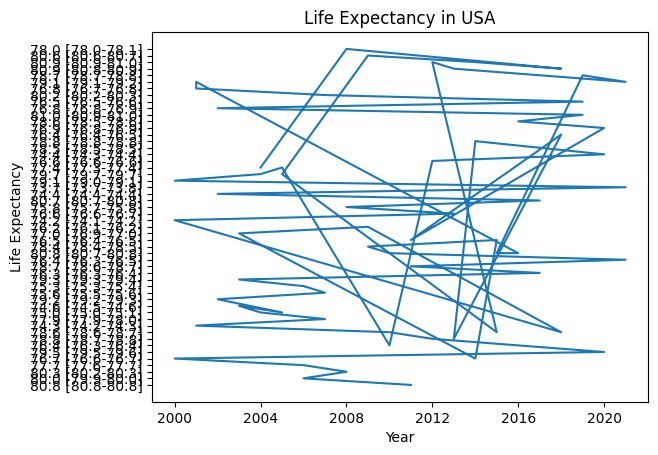

In [ ]:
import matplotlib.pyplot as plt

df_usa['TimeDimensionBegin'] = pd.to_datetime(df_usa['TimeDimensionBegin'])

plt.plot(df_usa['TimeDimensionBegin'], df_usa['Value'])
plt.title("Life Expectancy in USA")
plt.xlabel("Year")
plt.ylabel("Life Expectancy")
plt.show()

In [ ]:
import requests
import pandas as pd

# Pull data from WHO API
url = "https://ghoapi.azureedge.net/api/WHOSIS_000001"
response = requests.get(url)
data = response.json()

df = pd.DataFrame(data['value'])

# Filter for USA and Male (using 'SEX_MLE' for male life expectancy)
df_clean = df[
    (df['SpatialDim'] == 'USA') &   # USA only
    (df['Dim1'] == 'SEX_MLE')        # Male only
].copy()

In [ ]:
df_clean = df_clean[['TimeDimensionBegin', 'NumericValue']]

In [ ]:
df_clean.columns = ['Year', 'LifeExpectancy']

In [ ]:
df_clean['Year'] = pd.to_datetime(df_clean['Year'])

In [ ]:
df_clean = df_clean.sort_values(by='Year')

In [ ]:
df_clean.head()

,Year,LifeExpectancy
6160,2000-01-01 00:00:00+01:00,74.162603
2315,2001-01-01 00:00:00+01:00,74.277110
6875,2002-01-01 00:00:00+01:00,74.399880
3503,2003-01-01 00:00:00+01:00,74.572319
2733,2004-01-01 00:00:00+01:00,75.019245


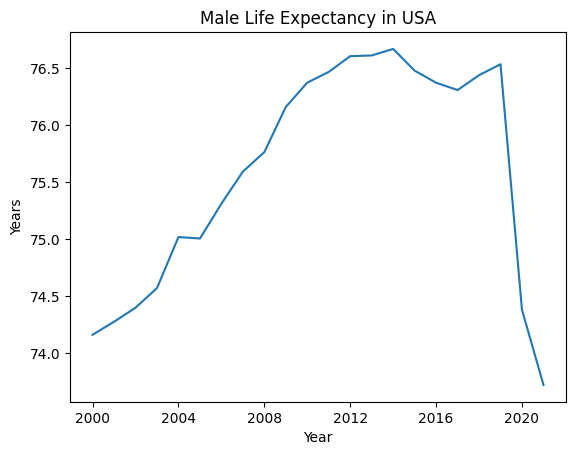

In [ ]:
import matplotlib.pyplot as plt

plt.plot(df_clean['Year'], df_clean['LifeExpectancy'])
plt.title("Male Life Expectancy in USA")
plt.xlabel("Year")
plt.ylabel("Years")
plt.show()

In [ ]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

# Indicator code for age-standardized death rates for ischaemic heart disease
indicator_code = 'SA_0000001444'

# API URL for USA data of this indicator
url = f"https://ghoapi.azureedge.net/api/{indicator_code}?$filter=SpatialDim eq 'USA'"

response = requests.get(url)
data = response.json()

# Convert to DataFrame
if 'value' in data and len(data['value']) > 0:
    df_heart_disease_male = pd.DataFrame(data['value'])

    # Convert 'TimeDimensionValue' to numeric, coercing errors to NaN
    df_heart_disease_male['TimeDimensionValue'] = pd.to_numeric(df_heart_disease_male['TimeDimensionValue'], errors='coerce')
    # Drop rows where 'TimeDimensionValue' became NaN (if any non-numeric values were present)
    df_heart_disease_male.dropna(subset=['TimeDimensionValue'], inplace=True);
    # Convert to integer type after dropping NaNs
    df_heart_disease_male['TimeDimensionValue'] = df_heart_disease_male['TimeDimensionValue'].astype(int)

    # Filter for the years 2000-2020 and for 'Male' (SEX_MLE)
    df_heart_disease_male_filtered = df_heart_disease_male[
        (df_heart_disease_male['TimeDimensionValue'] >= 2000) &
        (df_heart_disease_male['TimeDimensionValue'] <= 2020) &
        (df_heart_disease_male['Dim1'] == 'SEX_MLE')
    ].copy()

    # Ensure 'TimeDimensionBegin' is in datetime format and sort
    df_heart_disease_male_filtered['TimeDimensionBegin'] = pd.to_datetime(df_heart_disease_male_filtered['TimeDimensionBegin'])
    df_heart_disease_male_filtered = df_heart_disease_male_filtered.sort_values(by='TimeDimensionBegin')

    print("Filtered Heart Disease Data (2000-2020, Male) for USA:")
    display(df_heart_disease_male_filtered.head())
else:
    print(f"No data found for indicator: {indicator_code} in USA for the specified period.")
    df_heart_disease_male_filtered = pd.DataFrame()

Filtered Heart Disease Data (2000-2020, Male) for USA:


,Id,IndicatorCode,SpatialDimType,SpatialDim,ParentLocationCode,TimeDimType,ParentLocation,Dim1Type,TimeDim,Dim1,...,DataSourceDim,Value,NumericValue,Low,High,Comments,Date,TimeDimensionValue,TimeDimensionBegin,TimeDimensionEnd
1,7963562,SA_0000001444,COUNTRY,USA,AMR,YEAR,Americas,SEX,2004,SEX_MLE,...,None,127.2,127.2,None,None,None,2013-06-11T14:15:34+02:00,2004,2004-01-01 00:00:00+01:00,2004-12-31T00:00:00+01:00


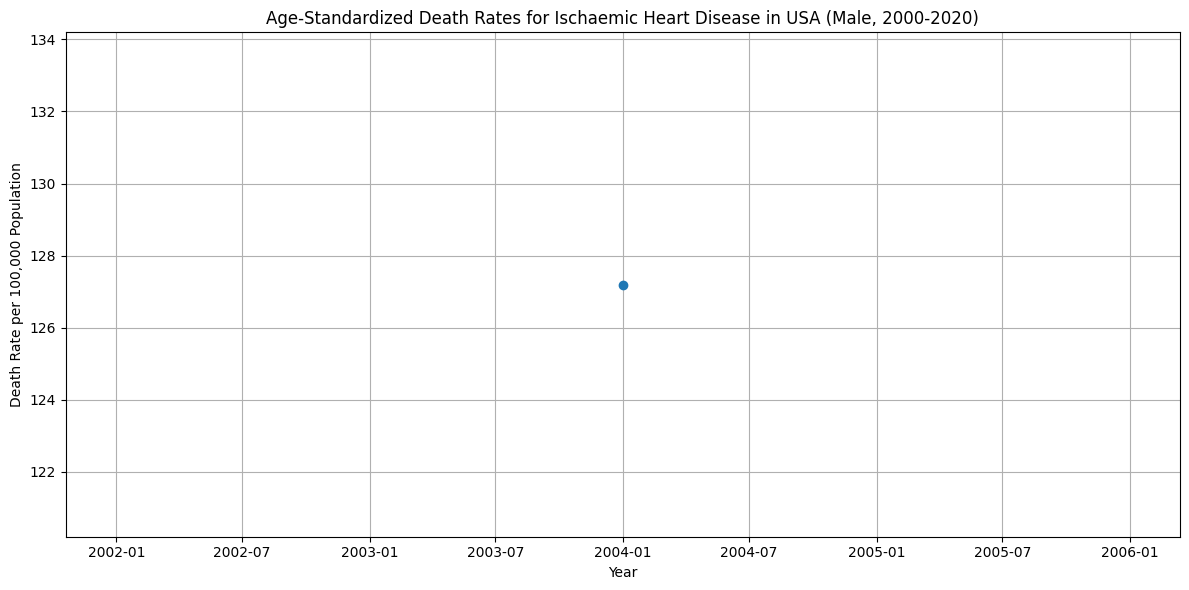

In [ ]:
if not df_heart_disease_male_filtered.empty:
    plt.figure(figsize=(12, 6))
    plt.plot(df_heart_disease_male_filtered['TimeDimensionBegin'], df_heart_disease_male_filtered['NumericValue'], marker='o', linestyle='-')
    plt.title('Age-Standardized Death Rates for Ischaemic Heart Disease in USA (Male, 2000-2020)')
    plt.xlabel('Year')
    plt.ylabel('Death Rate per 100,000 Population')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Cannot create plot: DataFrame is empty or no male data for the specified period.")

In [ ]:
# Filter df_usa for male life expectancy ('SEX_MLE')
df_usa_male = df_usa[df_usa['Dim1'] == 'SEX_MLE'].copy()

# Select relevant columns and rename them for clarity
df_usa_male = df_usa_male[['TimeDimensionBegin', 'NumericValue']]
df_usa_male.columns = ['Year', 'LifeExpectancy']

# Convert 'Year' to datetime objects and sort the DataFrame
df_usa_male['Year'] = pd.to_datetime(df_usa_male['Year'])
df_usa_male = df_usa_male.sort_values(by='Year')

# Display the head of the new DataFrame
display(df_usa_male.head())

,Year,LifeExpectancy
6160,2000-01-01 00:00:00+01:00,74.162603
2315,2001-01-01 00:00:00+01:00,74.277110
6875,2002-01-01 00:00:00+01:00,74.399880
3503,2003-01-01 00:00:00+01:00,74.572319
2733,2004-01-01 00:00:00+01:00,75.019245


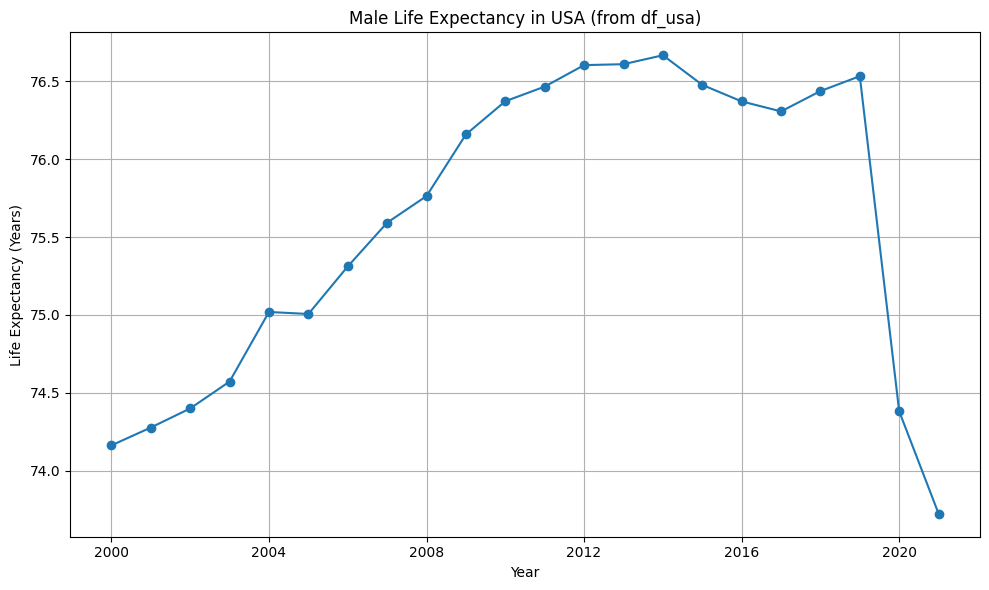

In [ ]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(df_usa_male['Year'], df_usa_male['LifeExpectancy'], marker='o', linestyle='-')
plt.title("Male Life Expectancy in USA (from df_usa)")
plt.xlabel("Year")
plt.ylabel("Life Expectancy (Years)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
print(df_usa.columns)

Index(['Id', 'IndicatorCode', 'SpatialDimType', 'SpatialDim',
       'ParentLocationCode', 'TimeDimType', 'ParentLocation', 'Dim1Type',
       'TimeDim', 'Dim1', 'Dim2Type', 'Dim2', 'Dim3Type', 'Dim3',
       'DataSourceDimType', 'DataSourceDim', 'Value', 'NumericValue', 'Low',
       'High', 'Comments', 'Date', 'TimeDimensionValue', 'TimeDimensionBegin',
       'TimeDimensionEnd'],
      dtype='object')


In [ ]:
df_usa.head()

,Id,IndicatorCode,SpatialDimType,SpatialDim,ParentLocationCode,TimeDimType,ParentLocation,Dim1Type,TimeDim,Dim1,...,DataSourceDim,Value,NumericValue,Low,High,Comments,Date,TimeDimensionValue,TimeDimensionBegin,TimeDimensionEnd
173,3078438,WHOSIS_000001,COUNTRY,USA,AMR,YEAR,Americas,SEX,2011,SEX_FMLE,...,None,80.8 [80.8-80.8],80.797122,80.750904,80.843339,None,2024-08-02T09:43:39.193+02:00,2011,2011-01-01 00:00:00+01:00,2011-12-31T00:00:00+01:00
544,3352210,WHOSIS_000001,COUNTRY,USA,AMR,YEAR,Americas,SEX,2006,SEX_FMLE,...,None,80.0 [79.9-80.0],79.992430,79.941158,80.043701,None,2024-08-02T09:43:39.193+02:00,2006,2006-01-01 00:00:00+01:00,2006-12-31T00:00:00+01:00
1583,238089,WHOSIS_000001,COUNTRY,USA,AMR,YEAR,Americas,SEX,2008,SEX_FMLE,...,None,80.3 [80.2-80.3],80.283724,80.237185,80.330263,None,2024-08-02T09:43:39.193+02:00,2008,2008-01-01 00:00:00+01:00,2008-12-31T00:00:00+01:00
1608,256636,WHOSIS_000001,COUNTRY,USA,AMR,YEAR,Americas,SEX,2006,SEX_BTSX,...,None,77.7 [77.6-77.7],77.683314,77.633223,77.733404,None,2024-08-02T09:43:39.193+02:00,2006,2006-01-01 00:00:00+01:00,2006-12-31T00:00:00+01:00
1668,298983,WHOSIS_000001,COUNTRY,USA,AMR,YEAR,Americas,SEX,2000,SEX_BTSX,...,None,76.7 [76.6-76.7],76.658476,76.612057,76.704896,None,2024-08-02T09:43:39.193+02:00,2000,2000-01-01 00:00:00+01:00,2000-12-31T00:00:00+01:00


In [ ]:
url = "https://ghoapi.azureedge.net/api/Indicator"
df = pd.DataFrame(requests.get(url).json()['value'])
df.head()

,IndicatorCode,IndicatorName,Language
0,HCF_NO_ELECTRICITY,Percentage of health-care facilities with no a...,EN
1,HIV_0000000006,Number of people dying from HIV-related causes,EN
2,HIV_0000000011,Reported number of children receiving antiretr...,EN
3,HIV_0000000012,Reported number of children receiving antiretr...,EN
4,HIV_0000000020,Estimated number of pregnant women living with...,EN


In [ ]:
!pip install requests pandas

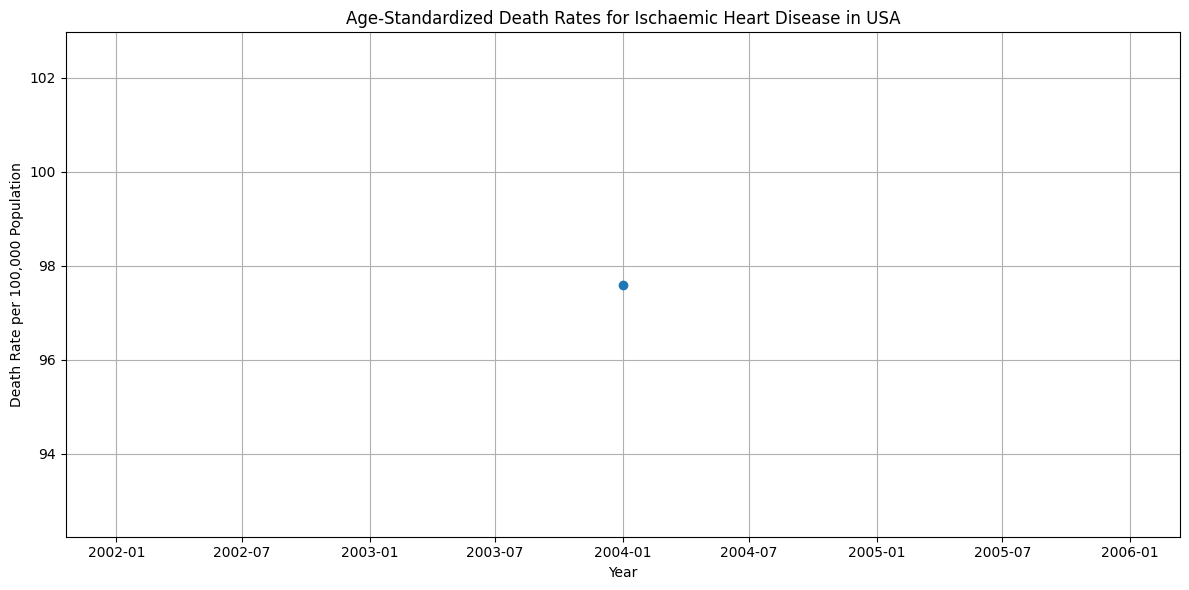

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'TimeDimensionBegin' is in datetime format and sort the DataFrame
df_heart_disease_usa['TimeDimensionBegin'] = pd.to_datetime(df_heart_disease_usa['TimeDimensionBegin'])
df_heart_disease_usa_sorted = df_heart_disease_usa.sort_values(by='TimeDimensionBegin')

# Filter for total population (Both sexes - 'SEX_BTSX') to avoid duplicate lines if multiple sexes are present for the same year
df_heart_disease_usa_total = df_heart_disease_usa_sorted[df_heart_disease_usa_sorted['Dim1'] == 'SEX_BTSX']

plt.figure(figsize=(12, 6))
plt.plot(df_heart_disease_usa_total['TimeDimensionBegin'], df_heart_disease_usa_total['NumericValue'], marker='o', linestyle='-')
plt.title('Age-Standardized Death Rates for Ischaemic Heart Disease in USA')
plt.xlabel('Year')
plt.ylabel('Death Rate per 100,000 Population')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
display(df_heart_disease_usa.describe())

,Id,TimeDim,NumericValue
count,3.000000e+00,3.0,3.000000
mean,5.976600e+06,2004.0,99.366667
std,4.057286e+06,0.0,26.993394
min,1.308809e+06,2004.0,73.300000
25%,4.636186e+06,2004.0,85.450000
50%,7.963562e+06,2004.0,97.600000
75%,8.310496e+06,2004.0,112.400000
max,8.657430e+06,2004.0,127.200000


The plot above shows the trend of age-standardized death rates for ischaemic heart disease in the USA over the years available in the dataset.

In [ ]:
indicator_code_heart_disease_deaths = 'SA_0000001444'
url_heart_disease_usa = f"https://ghoapi.azureedge.net/api/{indicator_code_heart_disease_deaths}?$filter=SpatialDim eq 'USA'"

response_hd = requests.get(url_heart_disease_usa)
data_hd = response_hd.json()

if 'value' in data_hd and len(data_hd['value']) > 0:
    df_heart_disease_usa = pd.DataFrame(data_hd['value'])
    print(f"Successfully loaded data for indicator: {indicator_code_heart_disease_deaths} in USA.")
    display(df_heart_disease_usa.head())
else:
    print(f"No data found for indicator: {indicator_code_heart_disease_deaths} in USA.")
    df_heart_disease_usa = pd.DataFrame()

Successfully loaded data for indicator: SA_0000001444 in USA.


,Id,IndicatorCode,SpatialDimType,SpatialDim,ParentLocationCode,TimeDimType,ParentLocation,Dim1Type,TimeDim,Dim1,...,DataSourceDim,Value,NumericValue,Low,High,Comments,Date,TimeDimensionValue,TimeDimensionBegin,TimeDimensionEnd
0,1308809,SA_0000001444,COUNTRY,USA,AMR,YEAR,Americas,SEX,2004,SEX_BTSX,...,None,97.6,97.6,None,None,None,2013-06-11T14:15:34+02:00,2004,2004-01-01T00:00:00+01:00,2004-12-31T00:00:00+01:00
1,7963562,SA_0000001444,COUNTRY,USA,AMR,YEAR,Americas,SEX,2004,SEX_MLE,...,None,127.2,127.2,None,None,None,2013-06-11T14:15:34+02:00,2004,2004-01-01T00:00:00+01:00,2004-12-31T00:00:00+01:00
2,8657430,SA_0000001444,COUNTRY,USA,AMR,YEAR,Americas,SEX,2004,SEX_FMLE,...,None,73.3,73.3,None,None,None,2013-06-11T14:15:34+02:00,2004,2004-01-01T00:00:00+01:00,2004-12-31T00:00:00+01:00


This DataFrame `df_heart_disease_usa` now contains the age-standardized death rates for ischaemic heart disease in the USA. You can now analyze or visualize this data further.

In [ ]:
heart_disease_indicators = df[df['IndicatorName'].str.contains('heart disease', case=False, na=False)]
display(heart_disease_indicators.head())

,IndicatorCode,IndicatorName,Language
480,NCD_CCS_rheumfollowup,Has systems for follow-up/recall to deliver lo...,EN
506,NCD_CCS_rheum,Provision for secondary prevention of rheumati...,EN
514,NCD_CCS_rheumreg,Existence of a register of patients who had rh...,EN
817,SA_0000001425,"Age-standardized DALYs, ischaemic heart diseas...",EN
897,SA_0000001444,"Age-standardized death rates, ischaemic heart ...",EN


Above are some of the indicators that contain 'heart disease' in their names. If you need a more specific indicator, please let me know some additional keywords.

In [ ]:
causes_of_death_indicators = df[df['IndicatorName'].str.contains('death', case=False, na=False) | df['IndicatorName'].str.contains('mortality', case=False, na=False)]
display(causes_of_death_indicators.head())

,IndicatorCode,IndicatorName,Language
74,AIR_11,Household air pollution attributable deaths,EN
75,AIR_13,Household air pollution attributable deaths pe...,EN
76,AIR_14,Household air pollution attributable deaths p...,EN
84,AIR_41,Ambient air pollution attributable deaths,EN
95,MENING_1,Number of suspected meningitis deaths reported,EN


In [ ]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

# Indicator code for age-standardized death rates for ischaemic heart disease
indicator_code = 'SA_0000001444'

# API URL for USA data of this indicator (fetching all available years first)
url = f"https://ghoapi.azureedge.net/api/{indicator_code}?$filter=SpatialDim eq 'USA'"

response = requests.get(url)
data = response.json()

# Convert to DataFrame
if 'value' in data and len(data['value']) > 0:
    df_heart_disease_full = pd.DataFrame(data['value'])

    # Convert 'TimeDimensionValue' to numeric, coercing errors to NaN
    df_heart_disease_full['TimeDimensionValue'] = pd.to_numeric(df_heart_disease_full['TimeDimensionValue'], errors='coerce')
    # Drop rows where 'TimeDimensionValue' became NaN (if any non-numeric values were present)
    df_heart_disease_full.dropna(subset=['TimeDimensionValue'], inplace=True)
    # Convert to integer type after dropping NaNs
    df_heart_disease_full['TimeDimensionValue'] = df_heart_disease_full['TimeDimensionValue'].astype(int)

    # Filter for the years 2000-2020 and for 'Both Sexes' (SEX_BTSX)
    df_heart_disease_filtered = df_heart_disease_full[
        (df_heart_disease_full['TimeDimensionValue'] >= 2000) &
        (df_heart_disease_full['TimeDimensionValue'] <= 2020) &
        (df_heart_disease_full['Dim1'] == 'SEX_BTSX')
    ].copy()

    # Ensure 'TimeDimensionBegin' is in datetime format and sort
    df_heart_disease_filtered['TimeDimensionBegin'] = pd.to_datetime(df_heart_disease_filtered['TimeDimensionBegin'])
    df_heart_disease_filtered = df_heart_disease_filtered.sort_values(by='TimeDimensionBegin')

    print("Filtered Heart Disease Data (2000-2020, Both Sexes) for USA:")
    display(df_heart_disease_filtered.head())
else:
    print(f"No data found for indicator: {indicator_code} in USA for the specified period.")
    df_heart_disease_filtered = pd.DataFrame()

Filtered Heart Disease Data (2000-2020, Both Sexes) for USA:


,Id,IndicatorCode,SpatialDimType,SpatialDim,ParentLocationCode,TimeDimType,ParentLocation,Dim1Type,TimeDim,Dim1,...,DataSourceDim,Value,NumericValue,Low,High,Comments,Date,TimeDimensionValue,TimeDimensionBegin,TimeDimensionEnd
0,1308809,SA_0000001444,COUNTRY,USA,AMR,YEAR,Americas,SEX,2004,SEX_BTSX,...,None,97.6,97.6,None,None,None,2013-06-11T14:15:34+02:00,2004,2004-01-01 00:00:00+01:00,2004-12-31T00:00:00+01:00


In [ ]:
display(heart_disease_indicators.head(10))

,IndicatorCode,IndicatorName,Language
480,NCD_CCS_rheumfollowup,Has systems for follow-up/recall to deliver lo...,EN
506,NCD_CCS_rheum,Provision for secondary prevention of rheumati...,EN
514,NCD_CCS_rheumreg,Existence of a register of patients who had rh...,EN
817,SA_0000001425,"Age-standardized DALYs, ischaemic heart diseas...",EN
897,SA_0000001444,"Age-standardized death rates, ischaemic heart ...",EN


In [ ]:
# Filter df_usa for female life expectancy ('SEX_FMLE')
df_usa_female = df_usa[df_usa['Dim1'] == 'SEX_FMLE'].copy()

# Select relevant columns and rename them for clarity
df_usa_female = df_usa_female[['TimeDimensionBegin', 'NumericValue']]
df_usa_female.columns = ['Year', 'LifeExpectancy']

# Convert 'Year' to datetime objects and sort the DataFrame
df_usa_female['Year'] = pd.to_datetime(df_usa_female['Year'])
df_usa_female = df_usa_female.sort_values(by='Year')

# Display the head of the new DataFrame
print("Female Life Expectancy (USA) - First 5 rows:")
display(df_usa_female.head())

Female Life Expectancy (USA) - First 5 rows:


,Year,LifeExpectancy
7240,2000-01-01 00:00:00+01:00,79.064222
11358,2001-01-01 00:00:00+01:00,79.138983
3775,2002-01-01 00:00:00+01:00,79.220137
4171,2003-01-01 00:00:00+01:00,79.333450
7572,2004-01-01 00:00:00+01:00,79.698208


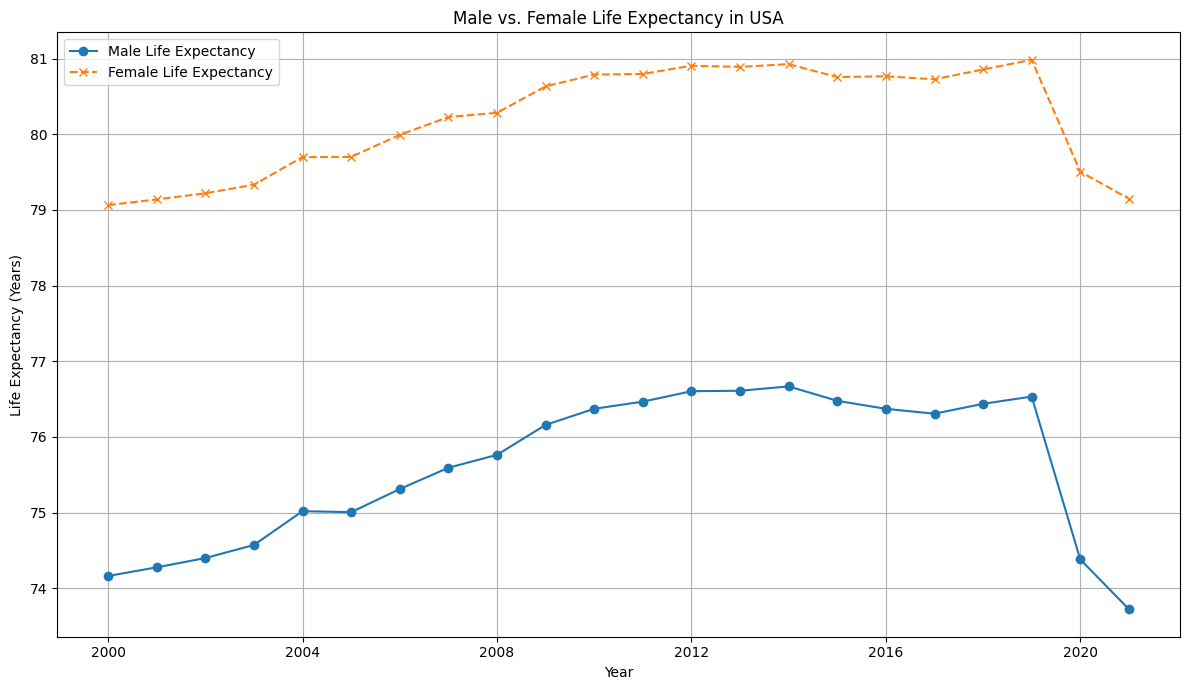

In [ ]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(12, 7))
plt.plot(df_usa_male['Year'], df_usa_male['LifeExpectancy'], marker='o', linestyle='-', label='Male Life Expectancy')
plt.plot(df_usa_female['Year'], df_usa_female['LifeExpectancy'], marker='x', linestyle='--', label='Female Life Expectancy')

plt.title("Male vs. Female Life Expectancy in USA")
plt.xlabel("Year")
plt.ylabel("Life Expectancy (Years)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
display(causes_of_death_indicators.head(10))

,IndicatorCode,IndicatorName,Language
74,AIR_11,Household air pollution attributable deaths,EN
75,AIR_13,Household air pollution attributable deaths pe...,EN
76,AIR_14,Household air pollution attributable deaths p...,EN
84,AIR_41,Ambient air pollution attributable deaths,EN
95,MENING_1,Number of suspected meningitis deaths reported,EN
121,imr,Infant mortality rate (deaths per 1000 live bi...,EN
145,LIFE_0000000029,nMx - age-specific death rate between ages x a...,EN
160,MORT_500,Number of deaths,EN
161,MORT_700,Projection of deaths per 100 000 population,EN
179,AIR_4,Ambient air pollution attributable deaths in c...,EN


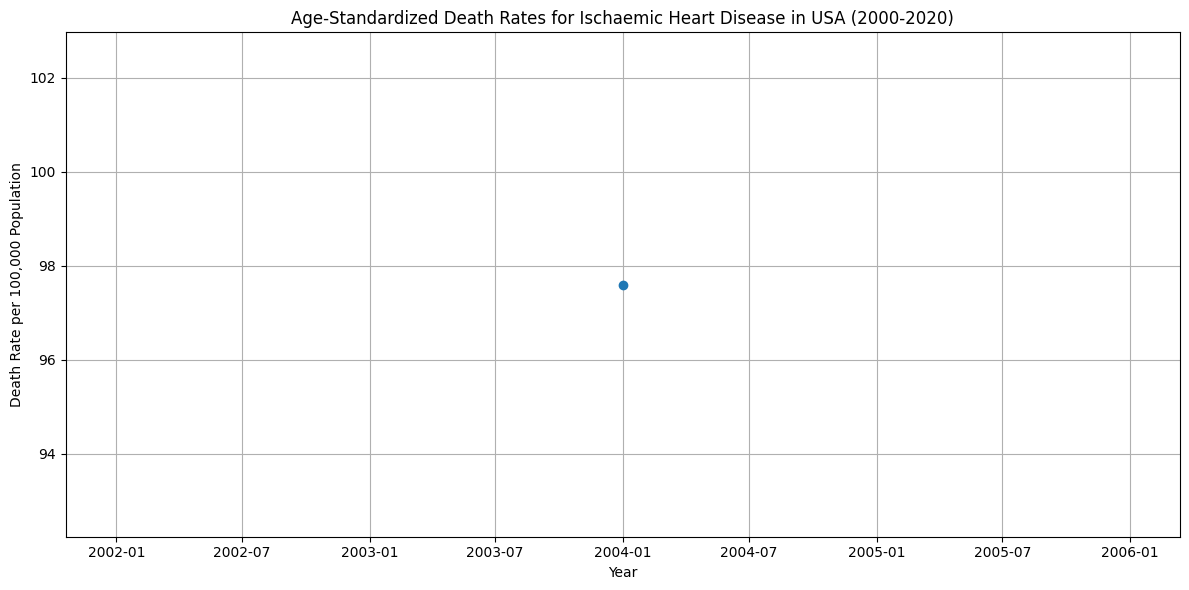

In [ ]:
if not df_heart_disease_filtered.empty:
    plt.figure(figsize=(12, 6))
    plt.plot(df_heart_disease_filtered['TimeDimensionBegin'], df_heart_disease_filtered['NumericValue'], marker='o', linestyle='-')
    plt.title('Age-Standardized Death Rates for Ischaemic Heart Disease in USA (2000-2020)')
    plt.xlabel('Year')
    plt.ylabel('Death Rate per 100,000 Population')
    plt.grid(True)
    plt.tight_layout()
    plt.show()
else:
    print("Cannot create plot: DataFrame is empty.")

Above are some of the indicators that contain 'death' or 'mortality' in their names. If you need a more specific indicator, please let me know some keywords.